# Project Title: Maternal Health Risk Analysis

# Project Overview
This exploratory data analysis investigates demographic and clinical characteristics associated with maternal health risk classifications. Using maternal health records, the project examines patterns in age, blood pressure, blood sugar, body temperature, and heart rate across low-, medium-, and high-risk groups. The goal is to communicate evidence-based insights clearly while recognising that the dataset can show associations—not causes.

## Business Problem
Maternal health complications can be influenced by several demographic and clinical measurements. Healthcare providers need clear, data-informed ways to identify patterns linked with higher observed risk so they can support appropriate monitoring and early intervention. This project explores which available measurements differ most across maternal risk categories.

### Project Objectives
- Describe the distribution of maternal health risk levels in the dataset.
- Assess data quality, including missing values, duplicates, data types, and unusual values.
- Compare age and clinical measurements across risk categories.
- Explore relationships among blood pressure, blood sugar, body temperature, and heart rate.
- Identify variables that appear most strongly associated with the recorded risk level.
- Communicate healthcare-relevant findings, limitations, and possible next steps responsibly.

###  Key Business Questions
- How are low-, medium-, and high-risk maternal records distributed?
- Does maternal age differ across risk categories?
- How do systolic and diastolic blood pressure vary by risk level?
- How does blood sugar vary across low-, mid-, and high-risk records?
- Do body temperature and heart rate show meaningful differences across risk groups?
- What relationships exist among the clinical measurements?
- Which available clinical measurements appear most strongly associated with maternal risk classification?
- Are clinical variables related to one another—for example, are systolic and diastolic blood pressure correlated?
- What patterns could help prioritise clinical monitoring?
- What conclusions can this dataset support, and what can it not establish?

### Dataset Description
The dataset contains approximately 1,014 maternal health records. Each row represents a recorded maternal-health observation with demographic and clinical measurements, alongside a risk classification.
| Column | Description |
|---|---|
| `Age` | Age of the mother, in years. |
| `SystolicBP` | Upper value of Blood Pressure in mmHg, another significant attribute during pregnancy. |
| `DiastolicBP` | Lower value of Blood Pressure in mmHg, another significant attribute during pregnancy. |
| `BS` | Blood glucose levels is in terms of a molar concentration(mmol) |
| `BodyTemp` | Body temperature measurement.(F) |
| `HeartRate` | Heart rate measurement(bpm). |
| `RiskLevel` |Predicted Risk Intensity Level during pregnancy considering the previous attribute. |

Data has been collected from different hospitals, community clinics, maternal health cares from the rural areas of Bangladesh through the IoT based risk monitoring system.

Data Source: Ahmed, M. (2020). Maternal Health Risk [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5DP5D.

### Tools and Libraries
- Pandas
- Matplotlib
- Seaborn
  

### Data Loading and Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data =r"C:\Users\USER\Downloads\maternal+health+risk\Maternal Health Risk Data Set.csv"
df= pd.read_csv(data)
print(df.head())
print(df.shape)
print(df.info())
print(df.dtypes)
print(df.isnull().sum())

   Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
0   25         130           80  15.0      98.0         86  high risk
1   35         140           90  13.0      98.0         70  high risk
2   29          90           70   8.0     100.0         80  high risk
3   30         140           85   7.0      98.0         70  high risk
4   35         120           60   6.1      98.0         76   low risk
(1014, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB
None
Age              i

The dataset contains 1014 Rows and 7 Columns. There are no missing values in the dataset and the data types are appropriate

In [3]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [4]:
# Converting temperature from fahrenheit to celsius
df=(
    df.assign(
        Temp = lambda x:(( x["BodyTemp"]-32) * 5/9).round(2)
    )
)
df[['Temp','BodyTemp']]
df=df.drop(columns ='BodyTemp')

BodyTemp was converted from Fahrenheit to Celsius to improve interpretability for a Nigerian healthcare audience.

### Duplicated Values

In [5]:
df.head()
print(df.duplicated().sum())
print(df.value_counts().head(20))
df.value_counts().value_counts().sort_index()

562
Age  SystolicBP  DiastolicBP  BS    HeartRate  RiskLevel  Temp 
19   120         80           7.0   70         mid risk   36.67    27
48   120         80           11.0  88         high risk  36.67    14
31   120         60           6.1   76         mid risk   36.67    13
40   160         100          19.0  77         high risk  36.67    10
55   140         95           19.0  77         high risk  36.67    10
32   140         90           18.0  88         high risk  36.67     9
54   140         100          15.0  66         high risk  36.67     9
40   120         95           11.0  80         high risk  36.67     7
42   120         80           7.5   70         low risk   36.67     7
32   120         90           7.5   70         low risk   36.67     7
31   120         60           6.1   76         low risk   36.67     7
19   120         80           7.0   70         low risk   36.67     7
29   130         70           7.5   78         mid risk   36.67     6
48   120         80   

count
1     148
2     198
3      54
4      24
5      11
6       5
7       5
9       2
10      2
13      1
14      1
27      1
Name: count, dtype: int64

In [6]:
df.duplicated().value_counts()

True     562
False    452
Name: count, dtype: int64

Duplicate assessment: The dataset contains 562 rows that are exact repetitions of previously occurring rows across all available variables. The dataset does not contain a unique identifier or observation ID, making it impossible to determine whether these repeated records represent duplicate entries or separate observations with identical characteristics. Therefore, the rows were retained rather than removed to avoid making an unsupported assumption about their validity.

#### Rearranging the columns

In [7]:
column_order = [col for col in df.columns if col != "RiskLevel"] + ["RiskLevel"]

df = df[column_order]
df

,Age,SystolicBP,DiastolicBP,BS,HeartRate,Temp,RiskLevel
0,25,130,80,15.0,86,36.67,high risk
1,35,140,90,13.0,70,36.67,high risk
2,29,90,70,8.0,80,37.78,high risk
3,30,140,85,7.0,70,36.67,high risk
4,35,120,60,6.1,76,36.67,low risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,80,36.67,high risk
1010,55,120,90,18.0,60,36.67,high risk
1011,35,85,60,19.0,86,36.67,high risk
1012,43,120,90,18.0,70,36.67,high risk


The columns were rearranged for readability

### Exploratory Data Analysis (EDA)

#### Understanding distribution of Maternal Age

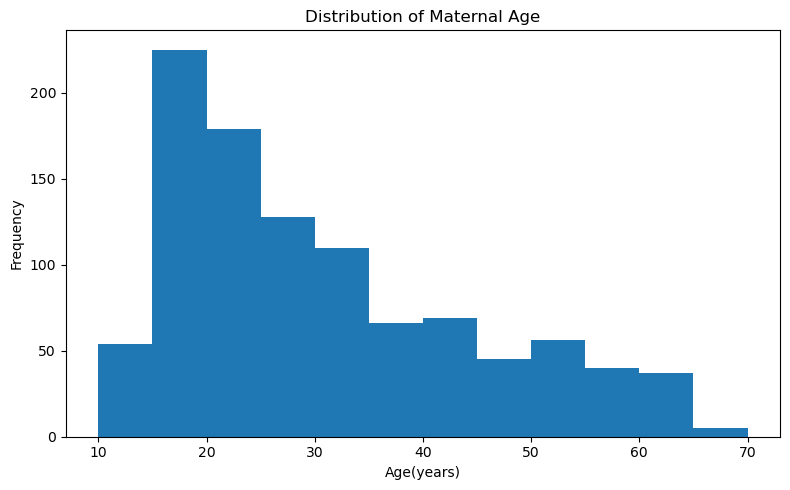

In [8]:
# Understanding age distribution
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(df["Age"], bins=12)

ax.set_xlabel("Age(years)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Maternal Age")
plt.tight_layout()
plt.show()

The maternal age distribution is right-skewed. Most records are concentrated among younger mothers, particularly between approximately 15 and 35 years, with the highest frequency in the 15–20 age group. The frequency generally declines after age 35, although there is a smaller concentration of records in the 40–50 age range. Very few records are observed among mothers aged approximately 65–70 years.

#### How are low-, medium-, and high-risk maternal records distributed?

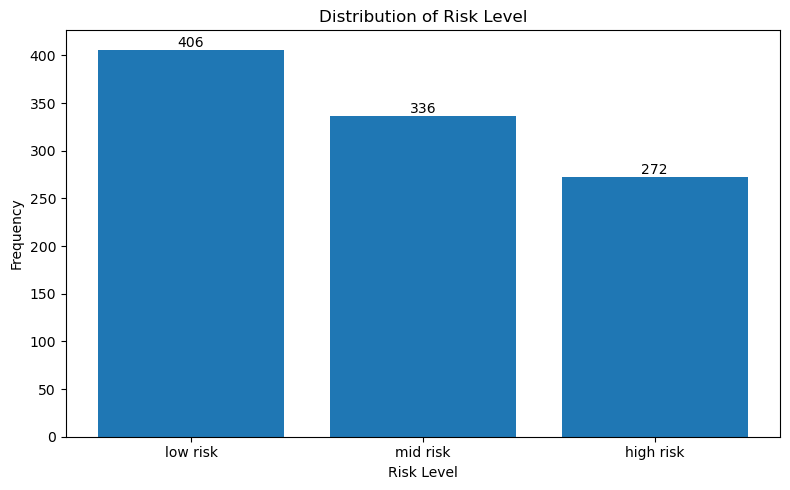

In [23]:
risk_count = df['RiskLevel'].value_counts()

fig, ax=plt.subplots(figsize=(8,5))

bar=ax.bar(risk_count.index,risk_count.values)
ax.bar_label(bar)
ax.set_xlabel("Risk Level")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Risk Level")

plt.savefig(r"C:\Users\USER\OneDrive\Documents\My files\portfolio\Python\Maternal_risk_analysis\images/age_risk_distribution.png",
            dpi=300,
            bbox_inches="tight")



plt.tight_layout()
plt.show()

From the distribution of the Risk Level, Low-risk records made up the largest proportion of the dataset, while high-risk records accounted for 26.82%. This distribution provides a basis for examining which demographic and clinical characteristics differ across the risk classifications.

#### Does maternal age differ across risk categories?

In [10]:
df['Age'].nunique()
age_bins = [10, 15, 20, 25, 30, 35, 40, float("inf")]

age_labels = ["10–14", "15–19", "20–24", "25–29", "30–34", "35–39", "40+"]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels,
    right=False,
    include_lowest=True
)

df["AgeGroup"].value_counts(sort=False)


AgeGroup
10–14     54
15–19    225
20–24    179
25–29    128
30–34    110
35–39     66
40+      252
Name: count, dtype: int64

Age-group classification: Maternal age was categorized into five-year age bands, following the age-disaggregation approach used in WHO maternal-health reporting, which specifically identifies 10–14 and 15–19 years for adolescents and recommends five-year age groups for relevant ages, including 20–24, 25–29, and 30–34 years. For this analysis, ages 35–39 were retained as a separate group, while ages 40 years and above were combined because of sparse representation across individual older ages in the dataset

In [11]:
age_risk=(pd.crosstab(
    df["AgeGroup"],
    df["RiskLevel"],
    normalize = "index"
) * 100).round(2)
age_risk


RiskLevel,high risk,low risk,mid risk
AgeGroup,,,
10–14,24.07,35.19,40.74
15–19,11.56,53.33,35.11
20–24,5.59,62.01,32.40
25–29,28.12,23.44,48.44
30–34,30.00,30.00,40.00
35–39,51.52,31.82,16.67
40+,47.62,28.57,23.81


#### Risk distribution across maternal age groups

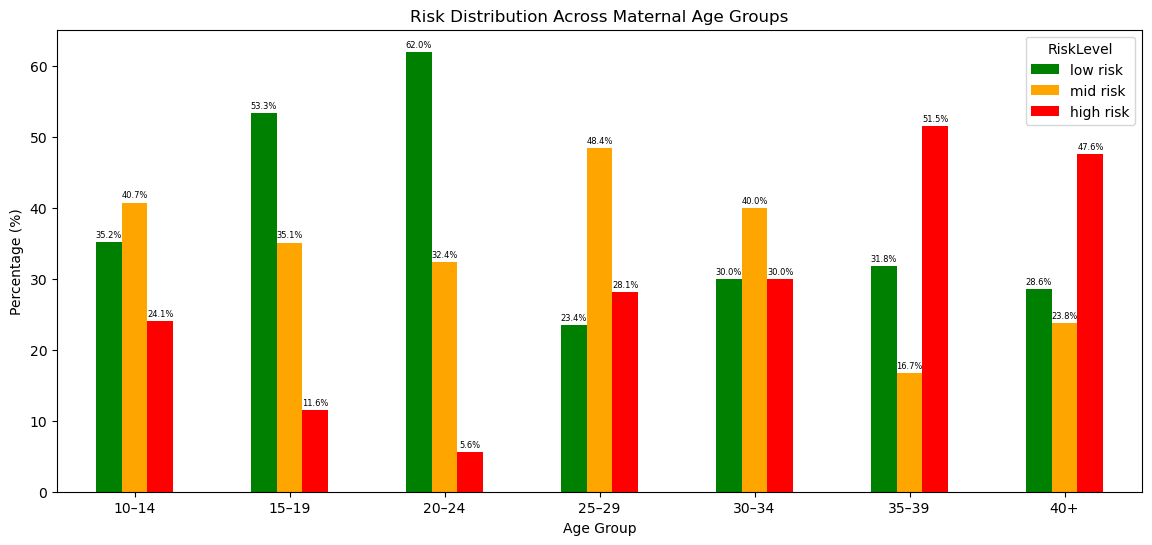

In [24]:
age_risk = age_risk[["low risk", "mid risk", "high risk"]]
fig, ax = plt.subplots(figsize=(14, 6))

age_risk.plot(kind="bar", 
              ax=ax,
               color=["green", "orange", "red"]
             )

for container in ax.containers:
    ax.bar_label(container,fmt="%.1f%%",fontsize=6, padding =2)

ax.set_xlabel("Age Group")
ax.set_ylabel("Percentage (%)")
ax.set_title("Risk Distribution Across Maternal Age Groups")
ax.tick_params(axis="x", labelrotation=0)

plt.savefig(r"C:\Users\USER\OneDrive\Documents\My files\portfolio\Python\Maternal_risk_analysis\images/risk_distribution_across_groups.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Interpretation: Risk classification varied considerably across age groups. Low-risk records were most prevalent among individuals aged 15–24, reaching approximately 62% in the 20–24 group. From ages 25–29 onward, the proportion of mid- and high-risk classifications increased, with high-risk records becoming the predominant classification among the 35–39 and 40+ groups. The 10–14 group showed a comparatively higher proportion of mid- and high-risk classifications, although this group contained fewer observations than several other age groups. These findings indicate an association between age group and risk classification in this dataset; however, the analysis does not establish that age causes increased maternal risk.

#### How does blood sugar vary across low-, mid-, and high-risk records?

In [13]:
risk_order = ["low risk", "mid risk", "high risk"]

df["RiskLevel"] = pd.Categorical(
    df["RiskLevel"],
    categories=risk_order,
    ordered=True
)

In [14]:
df['BS'].nunique()
df.groupby("RiskLevel",observed=True)["BS"].describe()

,count,mean,std,min,25%,50%,75%,max
RiskLevel,,,,,,,,
low risk,406.0,7.220271,0.645596,6.0,6.9,7.5,7.5,11.0
mid risk,336.0,7.795744,2.285511,6.0,6.8,7.0,7.8,18.0
high risk,272.0,12.122610,4.173525,6.1,7.9,11.0,15.0,19.0


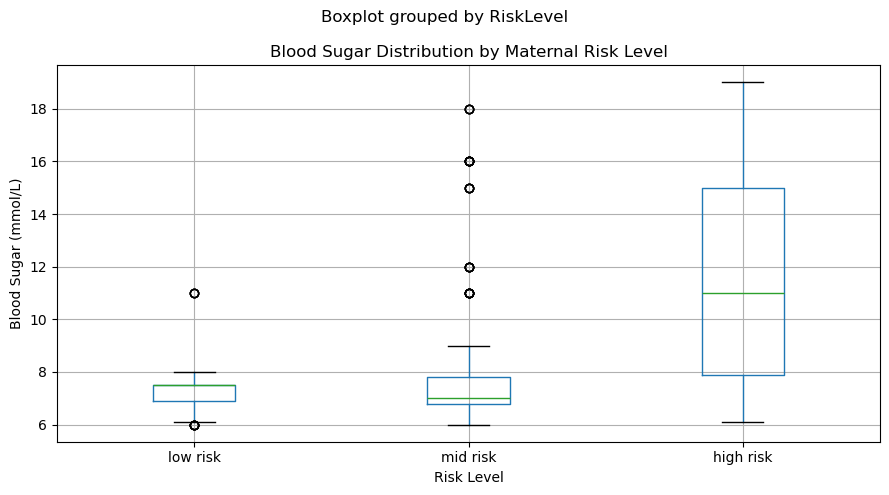

<Figure size 640x480 with 0 Axes>

In [25]:
fig, ax= plt.subplots(figsize = (9,5))

df.boxplot(
    column="BS",
    by="RiskLevel",
    ax=ax
)

ax.set_xlabel("Risk Level")
ax.set_ylabel("Blood Sugar (mmol/L)")
ax.set_title("Blood Sugar Distribution by Maternal Risk Level")
plt.tight_layout()
plt.show()

plt.savefig(r"C:\Users\USER\OneDrive\Documents\My files\portfolio\Python\Maternal_risk_analysis\images/blood_sugar_boxplot.png",
            dpi=300,
            bbox_inches="tight")

Blood sugar levels were substantially higher and more variable among high-risk records than among low- and mid-risk records. The low- and mid-risk groups had similar central distributions around 7 mmol/L, whereas the high-risk group had a median around 11 mmol/L and a much wider interquartile range. Several unusually high blood-sugar observations were also present among mid-risk records.

Higher blood sugar was associated with higher maternal risk classification in this dataset.

#### What relationships exist among the clinical measurements?

In [16]:
corr_matrix=(
    df
    .select_dtypes("number")
    .corr()
)
corr_matrix

,Age,SystolicBP,DiastolicBP,BS,HeartRate,Temp
Age,1.000000,0.416045,0.398026,0.473284,0.079798,-0.255300
SystolicBP,0.416045,1.000000,0.787006,0.425172,-0.023108,-0.286595
DiastolicBP,0.398026,0.787006,1.000000,0.423824,-0.046151,-0.257457
BS,0.473284,0.425172,0.423824,1.000000,0.142867,-0.103468
HeartRate,0.079798,-0.023108,-0.046151,0.142867,1.000000,0.098648
Temp,-0.255300,-0.286595,-0.257457,-0.103468,0.098648,1.000000


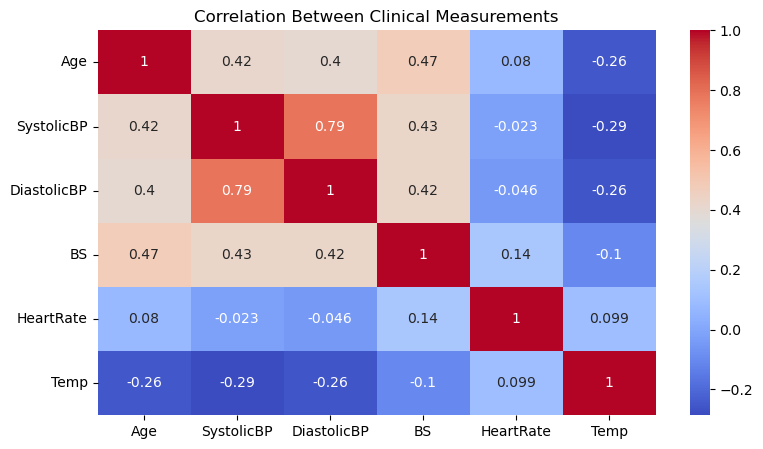

In [26]:
fig, ax = plt.subplots(figsize=(9,5))

sns.heatmap(corr_matrix, annot = True, cmap="coolwarm", ax=ax)

ax.set_title("Correlation Between Clinical Measurements")

plt.savefig(r"C:\Users\USER\OneDrive\Documents\My files\portfolio\Python\Maternal_risk_analysis\clinical_correlation.png",
            dpi=300,
            bbox_inches="tight")
plt.show()


Correlation analysis showed moderate positive associations between `blood sugar` and both `systolic` (r = 0.43) and `diastolic` blood pressure (r = 0.42). This suggests that higher blood sugar levels tend to occur alongside higher blood-pressure measurements in the dataset, although the associations are not strong and do not establish causation. The strong correlation between systolic and diastolic blood pressure (r = 0.79) was not explored further because the two measurements represent related components of blood pressure, making the association expected. Other clinical variables showed relatively weak linear relationships.

#### Relationship between blood sugar and blood pressure

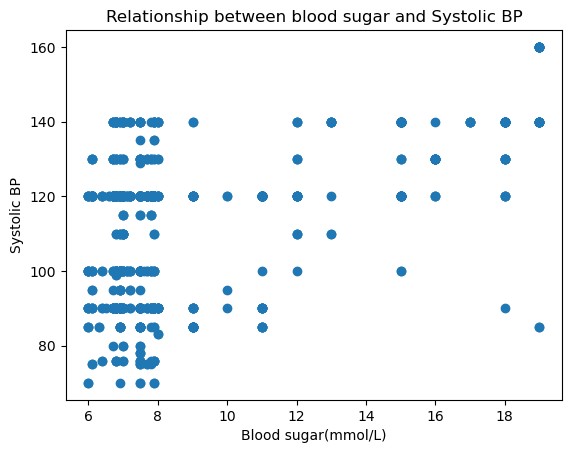

In [18]:
fig, ax= plt.subplots()

ax.scatter(df["BS"],df["SystolicBP"])
ax.set_xlabel("Blood sugar(mmol/L)")
ax.set_ylabel("Systolic BP")
ax.set_title("Relationship between blood sugar and Systolic BP")

plt.show()

"Blood sugar showed a moderate positive association with systolic blood pressure (r = 0.43). However, the scatterplot shows considerable variability in systolic BP across blood sugar levels, indicating that the relationship is not particularly strong."

### Which available clinical measurements appear most strongly associated with maternal risk classification?

In [19]:
df.groupby("RiskLevel",observed=True)[["Age", "SystolicBP", "DiastolicBP", "BS", "Temp", "HeartRate"]].mean()


,Age,SystolicBP,DiastolicBP,BS,Temp,HeartRate
RiskLevel,,,,,,
low risk,26.869458,105.866995,72.534483,7.220271,36.874458,72.770936
mid risk,28.363095,113.154762,74.232143,7.795744,37.131696,74.175595
high risk,36.216912,124.194853,85.073529,12.122610,37.168309,76.742647


Blood sugar and blood pressure showed the clearest differences in mean values across risk groups. Blood sugar showed the largest difference, increasing from a mean of 7.22 mmol/L in low-risk records to 12.12 mmol/L in high-risk records. Mean body temperature showed minimal variation across risk levels, while heart rate increased modestly from 72.77 bpm in low-risk records to 76.74 bpm in high-risk records. Overall, blood sugar and blood pressure appeared more strongly associated with the recorded risk classification than temperature and heart rate.


#### Exploring relationship between blood pressure and risk level

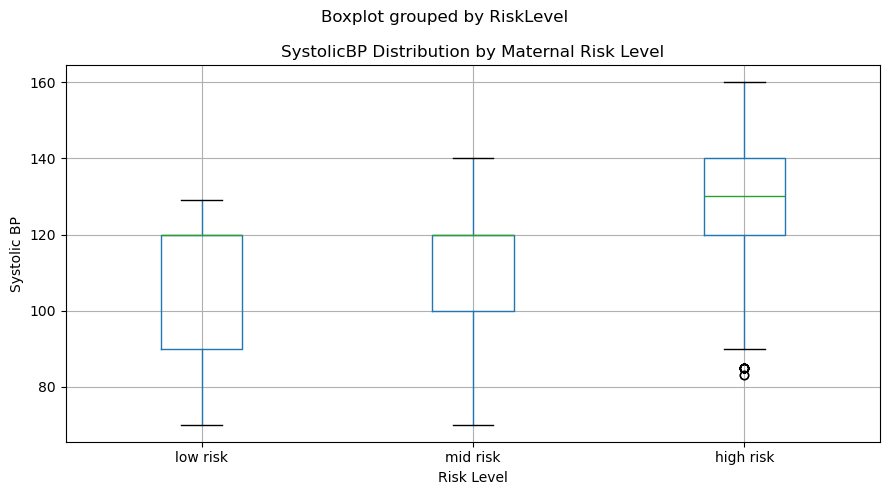

In [20]:
fig, ax= plt.subplots(figsize = (9,5))

df.boxplot(
    column="SystolicBP",
    by="RiskLevel",
    ax=ax
)

ax.set_xlabel("Risk Level")
ax.set_ylabel("Systolic BP")
ax.set_title("SystolicBP Distribution by Maternal Risk Level")
plt.tight_layout()
plt.show()

Systolic blood pressure showed an upward pattern across maternal risk levels, with high-risk records generally having higher systolic BP than low- and mid-risk records. However, there is considerable overlap between the groups, indicating that systolic BP alone does not clearly distinguish maternal risk levels. A few low systolic BP observations were identified as outliers in the high-risk group and should not be removed without further investigation.

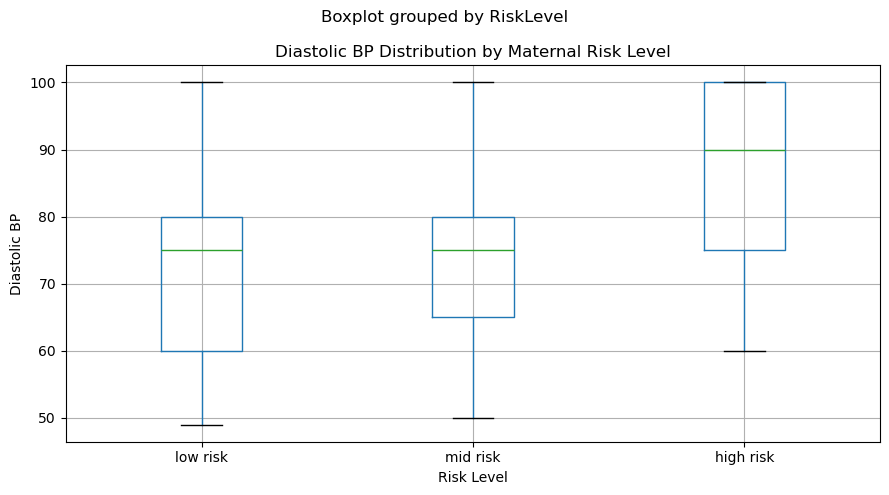

In [21]:
fig, ax= plt.subplots(figsize = (9,5))

df.boxplot(
    column="DiastolicBP",
    by="RiskLevel",
    ax=ax
)

ax.set_xlabel("Risk Level")
ax.set_ylabel("Diastolic BP")
ax.set_title("Diastolic BP Distribution by Maternal Risk Level")
plt.tight_layout()
plt.show()

Both systolic and diastolic blood pressure showed higher central values among high-risk records. While low- and mid-risk groups had similar diastolic BP distributions, the high-risk group had a noticeably higher median. Systolic BP also showed an upward shift among high-risk records. However, there was still overlap between risk groups, suggesting that blood pressure measurements are associated with risk classification, but there is considerable overlap between the groups.

#### Patterns relevant to clinical monitoring

The analysis identified several patterns that could potentially help prioritise clinical monitoring. Records classified as high risk tended to have higher blood sugar and blood pressure measurements, with blood sugar showing the largest difference across risk groups. Older age was also associated with higher average risk classification. Records exhibiting several of these characteristics simultaneously may warrant greater attention than records showing only one risk-associated characteristic.

In contrast, body temperature and heart rate showed relatively modest differences across risk groups. These findings describe patterns within the dataset and may help identify groups for further assessment, but they should not be interpreted as clinical decision rules or evidence that any individual measurement causes maternal risk.

#### Conclusion and Limitation
These findings suggest that blood sugar, blood pressure, and age may be useful characteristics for distinguishing records across the existing risk classifications. However, the analysis is descriptive and observational. It cannot establish that these variables cause maternal risk, independently predict risk, or define clinical thresholds for intervention. The findings also cannot be assumed to generalise to other maternal populations or healthcare settings without further validation. Therefore, the results should be interpreted as patterns within this dataset rather than clinical decision rules.